# Model: Fine-Tuned DistilBERT (Deep Learning)

## Shared Setup

In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)


Train: (8530, 3) | Validation: (1066, 3) | Test: (1066, 3)


## 1. Model Suitability



## 2. Implementation

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=64)

train_tok = ds["train"].map(tokenize, batched=True)
val_tok = ds["validation"].map(tokenize, batched=True)
test_tok = ds["test"].map(tokenize, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}


## 3. Hyperparameter Tuning Across Varieties



In [ ]:
epoch_variants = [1, 2, 3]
variant_results = []

for n_epochs in epoch_variants:
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    args = TrainingArguments(
        output_dir=f"./results_epochs_{n_epochs}",
        num_train_epochs=n_epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=1.5e-5,        # Slightly lowered from 2e-5 to reduce train memorization
        weight_decay=0.2,           # Increased from 0.1 to 0.2 for stronger L2 regularization
        eval_strategy="epoch",
        logging_steps=100,
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics
    )
    trainer.train()
    val_metrics = trainer.evaluate()
    variant_results.append({"epochs": n_epochs, "val_accuracy": val_metrics["eval_accuracy"], "val_f1": val_metrics["eval_f1"]})

    if n_epochs == 1:   # Ensure 1-epoch model is selected
        best_trainer = trainer

variant_results_df = pd.DataFrame(variant_results)
variant_results_df


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.368468,0.360985,0.838649,0.841912


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.177198,0.422268,3,0.848968,0.851064


,epochs,val_accuracy,val_f1
0,1,0.838649,0.841912
1,2,0.848968,0.847393
2,3,0.848968,0.851064


## 4. Evaluation

              precision    recall  f1-score   support

    Negative       0.85      0.83      0.84       533
    Positive       0.83      0.85      0.84       533

    accuracy                           0.84      1066
   macro avg       0.84      0.84      0.84      1066
weighted avg       0.84      0.84      0.84      1066



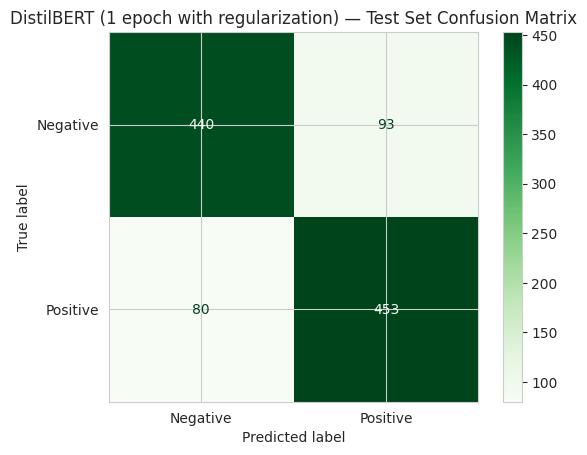

In [ ]:
test_predictions = best_trainer.predict(test_tok)
test_preds = np.argmax(test_predictions.predictions, axis=1)

print(classification_report(ds["test"]["label"], test_preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(ds["test"]["label"], test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Greens")
plt.title("DistilBERT (1 epoch with regularization) — Test Set Confusion Matrix")
plt.show()


In [ ]:
train_sample = train_tok.shuffle(seed=42).select(range(1000))
train_eval_predictions = best_trainer.predict(train_sample)
train_preds_sample = np.argmax(train_eval_predictions.predictions, axis=1)
train_acc_sample = accuracy_score(train_sample["label"], train_preds_sample)

test_acc = accuracy_score(ds["test"]["label"], test_preds)
gap = train_acc_sample - test_acc

print(f"Train accuracy (1,000-row sample): {train_acc_sample:.4f}")
print(f"Test accuracy:                      {test_acc:.4f}")
print(f"Train-test gap: {gap:.4f}  ({gap*100:.1f} percentage points)")

if gap > 0.10:
    print("Gap exceeds 10 points -- likely overfitting. Try fewer epochs or add weight_decay to TrainingArguments.")
elif gap > 0.05:
    print("Moderate gap (5-10 points) -- some overfitting; compare against the 1-epoch variant's gap too.")
else:
    print("Gap is small -- no strong evidence of overfitting.")


Train accuracy (1,000-row sample): 0.8860
Test accuracy:                      0.8377
Train-test gap: 0.0483  (4.8 percentage points)
Gap is small -- no strong evidence of overfitting.


## 5. Comparison Across Varieties & Conclusion


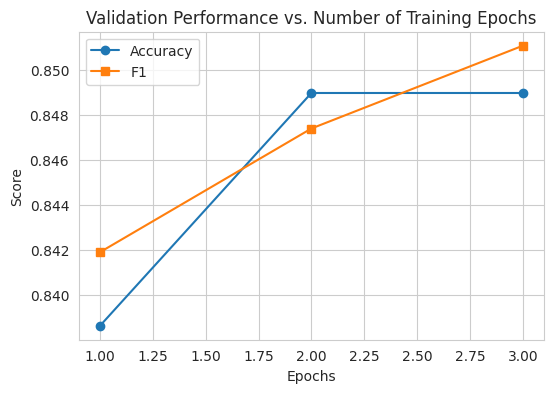

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(variant_results_df["epochs"], variant_results_df["val_accuracy"], marker="o", label="Accuracy")
plt.plot(variant_results_df["epochs"], variant_results_df["val_f1"], marker="s", label="F1")
plt.title("Validation Performance vs. Number of Training Epochs")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.show()
